#### - スケーリング前 : `New Fish`データが青色の点の近くに見えるが、KNNアルゴリズムでは「青1、オレンジ4」が選択される。
（`Weight`の数値の桁がはるかに大きいため、距離計算では`Weight`の影響が非常に大きくなる）
<span style="color:red;">→ New FishデータはSmelt（0）と予測される。</span>

<img src="../images/image-69_1.png" width="600">

- 見た目上の距離と、KNNが数値として計算する距離は必ずしも一致しない。

- KNNでは、`Length`と`Weight`の差を同時に用いてユークリッド距離を計算する。
スケーリング前は`Weight`の数値範囲が`Length`よりはるかに大きいため、距離計算では`Weight`の差が強く反映される。

<br>

#### - スケーリング後：散布図の横軸・縦軸を同じような尺度にスケーリングすることで、2変数のスケールが近い状態になる。

<img src="../images/image-69_2.png" width="600">

<br>

In [1]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

<br>

## 1. データの準備

In [2]:
fish = pd.read_csv(
    "https://raw.githubusercontent.com/rickiepark/hg-mldl/master/fish.csv"
)

# BreamとSmeltのみを選択
fish = fish[fish["Species"].isin(["Bream", "Smelt"])]

<br>

## 2. 入力データ（X）、ターゲットデータ（y）

In [3]:
X_train = fish[["Length", "Weight"]]

# Bream = 1、Smelt = 0
y_train = fish["Species"].map({
    "Bream": 1,
    "Smelt": 0
})

<br>

## 3. 新しい魚を指定

In [4]:
# Length = 25
# Weight = 150
new_fish = [[25, 150]]

<br>

## 4. スケーリング前の散布図

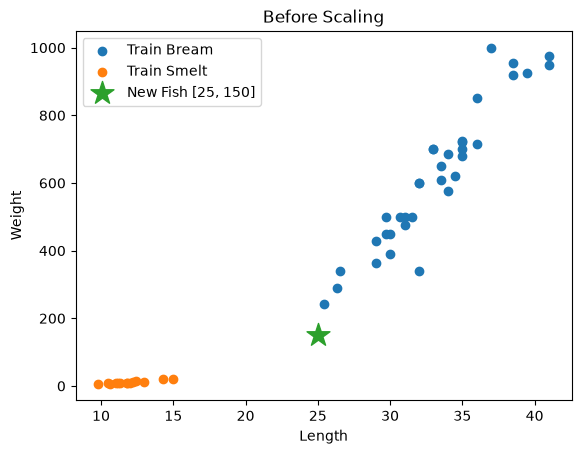

In [5]:
plt.figure()

# 訓練データ - Bream
plt.scatter(
    X_train[y_train == 1]["Length"],
    X_train[y_train == 1]["Weight"],
    label="Train Bream"
)

# 訓練データ - Smelt
plt.scatter(
    X_train[y_train == 0]["Length"],
    X_train[y_train == 0]["Weight"],
    label="Train Smelt"
)

# 新しい魚
plt.scatter(
    25,
    150,
    marker="*",
    s=300,
    label="New Fish [25, 150]"
)

plt.xlabel("Length")
plt.ylabel("Weight")
plt.title("Before Scaling")
plt.legend()
plt.show()

<br>

## 5. スケーリング前のKNN学習

In [ ]:
kn = KNeighborsClassifier(n_neighbors=5)

# 元のデータで学習
kn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


<br>

## 6. スケーリング前の新しい魚を予測

In [13]:
predict = kn.predict(new_fish)

print("スケーリング前の予測:", predict)

if predict[0] == 1:
    print("予測結果: Bream")
else:
    print("予測結果: Smelt")

スケーリング前の予測: [0]
予測結果: Smelt


<br>

## 7. 標準化

In [ ]:
scaler = StandardScaler()

# 訓練データの平均と標準偏差を求めた後、標準化
# fit_transform()メソッドはfit() + transform()の役割
X_train_scaled = scaler.fit_transform(X_train)

# fit()またはfit_transform()の前にtransform()を呼び出すとError
# 新しい魚は訓練データの基準
# （すでにfit_transform()で学習した平均・標準偏差）を使って標準化
new_fish_scaled = scaler.transform(new_fish)

<br>

## 8. スケーリング後の散布図

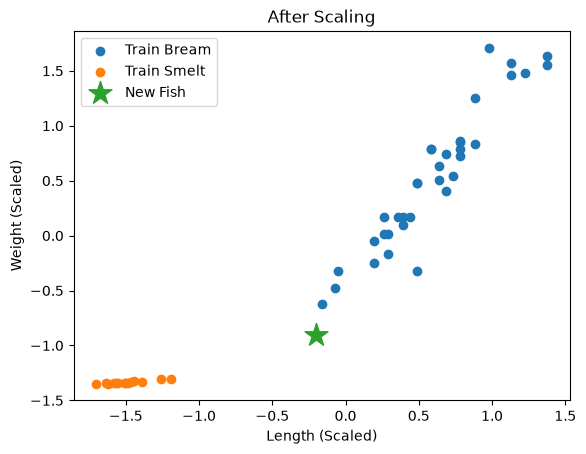

In [9]:
plt.figure()

# 訓練データ - Bream
plt.scatter(
    X_train_scaled[y_train == 1, 0],
    X_train_scaled[y_train == 1, 1],
    label="Train Bream"
)

# 訓練データ - Smelt
plt.scatter(
    X_train_scaled[y_train == 0, 0],
    X_train_scaled[y_train == 0, 1],
    label="Train Smelt"
)

# 新しい魚
plt.scatter(
    new_fish_scaled[0, 0],
    new_fish_scaled[0, 1],
    marker="*",
    s=300,
    label="New Fish"
)

plt.xlabel("Length (Scaled)")
plt.ylabel("Weight (Scaled)")
plt.title("After Scaling")
plt.legend()
plt.show()

<br>

## 9. スケーリング後のKNN学習

In [10]:
kn_scaled = KNeighborsClassifier(n_neighbors=5)

# 標準化したデータで学習
kn_scaled.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


<br>

## 10. スケーリング後の新しい魚を予測

In [11]:
predict_scaled = kn_scaled.predict(new_fish_scaled)

print("スケーリング後の予測:", predict_scaled)

if predict_scaled[0] == 1:
    print("予測結果: Bream")
else:
    print("予測結果: Smelt")

スケーリング後の予測: [1]
予測結果: Bream


<br>

#### スケーリング前後でKNNアルゴリズムが選択した最も近い5個のデータと距離を出力

- `kneighbors()`メソッドを使用
- 戻り値の型：`(numpy.ndarray, numpy.ndarray)`

In [15]:
distances, indexes = kn.kneighbors(new_fish)

print("\n[スケーリング前]")
print("距離:", distances[0])  # new_fishの1番目の入力データに対する結果
print("インデックス:", indexes[0])  # new_fishの1番目の入力データに対する結果

print("\n最も近い5個のデータ")

for distance, index in zip(distances[0], indexes[0]):
    length = X_train.iloc[index]["Length"]
    weight = X_train.iloc[index]["Weight"]
    species = fish.iloc[index]["Species"]

    print(
        f"距離={distance:.2f}, "
        f"座標=({length}, {weight}), "
        f"種類={species}"
    )


[スケーリング前]
距離: [ 92.00086956 130.48375378 130.73859415 137.17988191 138.32150953]
インデックス: [ 0 48 47 45 46]

最も近い5個のデータ
距離=92.00, 座標=(25.4, 242.0), 種類=Bream
距離=130.48, 座標=(15.0, 19.9), 種類=Smelt
距離=130.74, 座標=(14.3, 19.7), 種類=Smelt
距離=137.18, 座標=(12.4, 13.4), 種類=Smelt
距離=138.32, 座標=(13.0, 12.2), 種類=Smelt


<br>

In [16]:
distances_scaled, indexes_scaled = kn_scaled.kneighbors(
    new_fish_scaled
)

print("\n[スケーリング後]")
print("距離:", distances_scaled[0])
print("インデックス:", indexes_scaled[0])

print("\n最も近い5個のデータ")

for distance, index in zip(distances_scaled[0], indexes_scaled[0]):
    length = X_train.iloc[index]["Length"]
    weight = X_train.iloc[index]["Weight"]
    species = fish.iloc[index]["Species"]

    print(
        f"距離={distance:.2f}, "
        f"元の座標=({length}, {weight}), "
        f"種類={species}"
    )


[スケーリング後]
距離: [0.28600552 0.44973353 0.60343696 0.76537512 0.88843968]
インデックス: [0 1 2 3 7]

最も近い5個のデータ
距離=0.29, 元の座標=(25.4, 242.0), 種類=Bream
距離=0.45, 元の座標=(26.3, 290.0), 種類=Bream
距離=0.60, 元の座標=(26.5, 340.0), 種類=Bream
距離=0.77, 元の座標=(29.0, 363.0), 種類=Bream
距離=0.89, 元の座標=(30.0, 390.0), 種類=Bream
